<a href="https://colab.research.google.com/github/kowsikchowdarykiet-hue/Musical-Instrument-Frequency-Analyzer-/blob/main/Sample_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Simple inputs
m = float(input("Enter mass (kg): "))
k = float(input("Enter spring stiffness (N/m): "))

print("Mass =", m, "kg")
print("Spring stiffness =", k, "N/m")

Enter mass (kg): 2
Enter spring stiffness (N/m): 5
Mass = 2.0 kg
Spring stiffness = 5.0 N/m


In [4]:
M = np.array([
    [m, 0],
    [0, m]
])

K = np.array([
    [2*k, -k],
    [-k, 2*k]
])

print("Mass matrix M:")
print(M)

print("\nStiffness matrix K:")
print(K)

Mass matrix M:
[[2. 0.]
 [0. 2.]]

Stiffness matrix K:
[[10. -5.]
 [-5. 10.]]


In [5]:
# Solve the generalized eigenvalue problem
A = np.linalg.inv(M) @ K

eigenvalues, eigenvectors = np.linalg.eigh(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.5 7.5]

Eigenvectors:
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


In [6]:
omega = np.sqrt(eigenvalues)
frequency = omega / (2 * np.pi)

print("Natural frequencies:")

for i in range(len(frequency)):
    print(f"Mode {i+1}: {frequency[i]:.2f} Hz")

Natural frequencies:
Mode 1: 0.25 Hz
Mode 2: 0.44 Hz


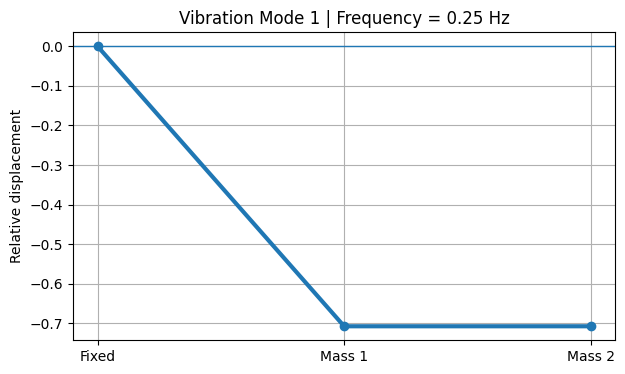

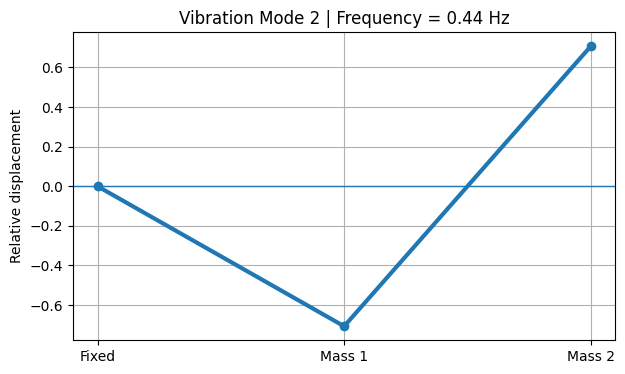

In [7]:
for i in range(2):

    mode = eigenvectors[:, i]

    plt.figure(figsize=(7, 4))

    # Fixed points
    x = np.array([0, 1, 2])

    # Add zero displacement at both ends
    y = np.array([0, mode[0], mode[1]])

    plt.plot(x, y, "o-", linewidth=3)

    plt.axhline(0, linewidth=1)

    plt.xticks(x, ["Fixed", "Mass 1", "Mass 2"])
    plt.ylabel("Relative displacement")

    plt.title(
        f"Vibration Mode {i+1} | "
        f"Frequency = {frequency[i]:.2f} Hz"
    )

    plt.grid(True)
    plt.show()